In [1]:
# Importing standard python libraries
%matplotlib inline
import matplotlib.pyplot as plt

In [2]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

from qiskit.visualization import plot_distribution, plot_bloch_multivector
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Statevector
from qiskit.result import Counts

import numpy as np

In [3]:
def qrng_n_bits(n):
    qc = QuantumCircuit(n, n)

    # Superposición uniforme
    for i in range(n):
        qc.ry(np.pi / 3, i)
    
    return qc

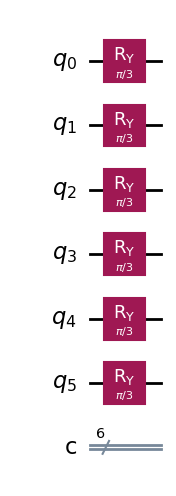

In [4]:
n = 6
circuit = qrng_n_bits(n)
circuit.draw('mpl')
plt.show()

In [5]:
display(array_to_latex(Statevector(circuit), prefix="\\ket{\\psi_{out}} = "))

<IPython.core.display.Latex object>

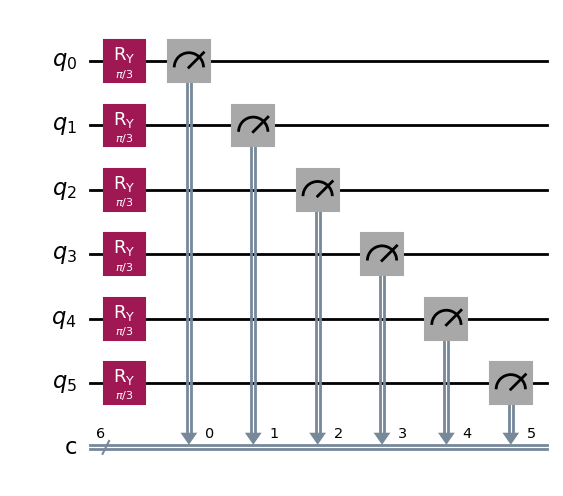

In [6]:
shots = 8192
circuit.measure(range(n), range(n))
circuit.draw('mpl')
plt.show()

In [7]:
sim = AerSimulator()
compiled = transpile(circuit, sim)
result = sim.run(compiled, shots=shots).result()
counts = result.get_counts()

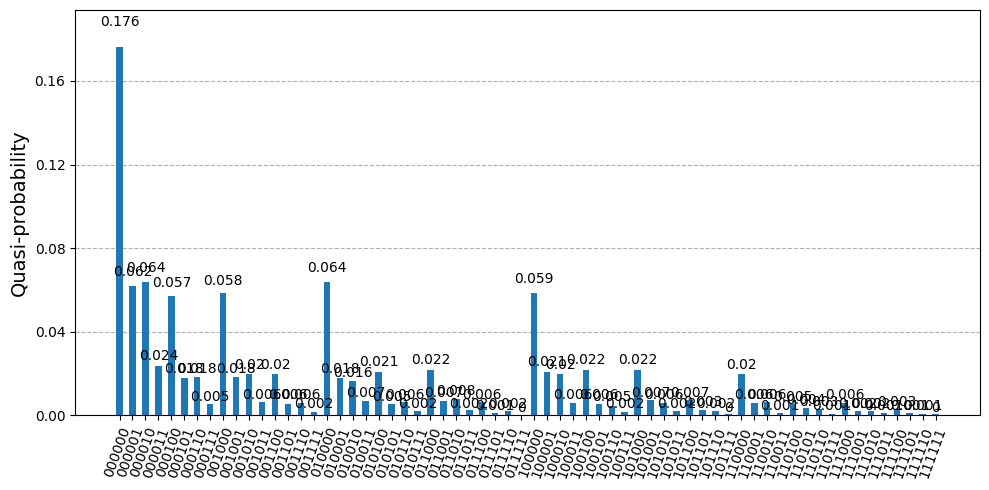

In [8]:
# Probabilidades de medición de cada salida, dada la ejecución real realizada.
plot_distribution(counts, figsize=(10, 5))
plt.show()

In [9]:
min = -100
max = 100

In [10]:
RandomResult = sim.run(compiled, shots=1).result()
RandomCounts = RandomResult.get_counts()

In [11]:
print('Conteo de resultados por cada medida: ', RandomCounts, '\n')

Conteo de resultados por cada medida:  {'110001': 1} 



In [12]:
random_obtained = Counts(RandomCounts).most_frequent()
print(random_obtained)

110001


In [13]:
resultado = int(random_obtained, 2) #https://www.programiz.com/python-programming/methods/built-in/int
print('El resultado binario como un entero decimal es: ', resultado, '\n')

El resultado binario como un entero decimal es:  49 



In [14]:
random_number = min + resultado % ((max+1) - min)
print('El numero aleatorio entre',min ,'y',max, 'es:', random_number, '\n')

El numero aleatorio entre -100 y 100 es: -51 

